# 03 — TCN WFO v2 Local Artifact Builder

Local, reproducible TCN walk-forward notebook.

This version deliberately separates model skill from bracket/beta effects:

- Walk-forward retraining, expanding window by default, every 3 months.
- 48-hour embargo between train and each prediction fold.
- Fold-local percentile calibration for TCN probabilities.
- Trading parameters selected on `2023-06-01 -> 2024-05-31`; OOS remains held out.
- Artifacts are written directly to `artifacts/notebooks_v2/03_tcn`.
- No Colab, Drive, download, or zip steps.
- Grid rows include always-long/always-short baselines and `skill_delta` metrics.
- The selected TCN configuration is chosen by incremental skill over the matching baseline, not raw return.

If the convex long bracket is the thing making money, it is reported as a baseline instead of being credited to the TCN.


## 0 · Environment

In [1]:
import calendar, itertools, json, math, random, time, warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("seaborn-whitegrid")
mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 10, "axes.titlesize": 11, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
ACCENT = "#F7931A"; BLUE = "#2962FF"; GREY = "#9E9E9E"; RED = "#EF5350"; GREEN = "#26A69A"; PURPLE = "#7E57C2"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)


Device: mps


## 1 · Configuration

In [2]:
# ── Local data/artifacts ─────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "hybrid-multi-agent-trading-system":
    # Allows running from src/hmats/notebooks_v2 while still resolving repo-local paths.
    for parent in Path.cwd().parents:
        if parent.name == "hybrid-multi-agent-trading-system":
            PROJECT_ROOT = parent
            break

DATA_PATH = PROJECT_ROOT / "data/features/BTCUSDT_1h_unified.parquet"
ARTS_DIR = PROJECT_ROOT / "artifacts/notebooks_v2/03_tcn"
ARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Unified split discipline ─────────────────────────────────────────────────
GRID_VAL_START = pd.Timestamp("2023-06-01")
GRID_VAL_END = pd.Timestamp("2024-05-31 23:00:00")
OOS_START = pd.Timestamp("2024-06-01")
OOS_END = pd.Timestamp("2026-05-31 23:00:00")
WFO_START = GRID_VAL_START
RETRAIN_MONTHS = 3
WFO_SCHEME = "expanding"
TRAIN_WINDOW_MONTHS = 36
EMBARGO_H = 48
VAL_FRAC = 0.15

# ── TCN / label spec ─────────────────────────────────────────────────────────
TBM_VOL_WINDOW = 24
TBM_MULT = 2.0
TBM_VERT_H = 24
FRAC_D = 0.4
FFD_THRES = 1e-4
SEQ_LEN = 48
TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL = 3
TCN_DROPOUT = 0.20
EPOCHS = 80
BATCH_SIZE = 256
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10
LAMBDA_VOL = 0.50
AUX_FWD_H = 6

# ── Execution model ──────────────────────────────────────────────────────────
MAKER_FEE = 0.0
SPOT_TAKER_FEE = 0.0005
FUTURES_TAKER_FEE = 0.0005
BUFFER = 0.0005
SHORT_FUNDING_H = 0.0000077
MIN_SL = 0.010
ANN = np.sqrt(24 * 365)

# Same compact feature family as static 03_tcn_v1 for comparability.
LGBM_CORE = ["stoch_k_14", "ret_2h", "rsi_divergence", "close_vs_sma_7", "bear_streak",
             "close_vs_s1", "macd_hist_5_13", "ad_z_48h", "ret_3h"]
V1_EXTRA = ["ret_1h", "rsi_14", "vol_ratio_24h", "bb_position_20", "hour_sin", "hour_cos",
            "atr_14_pct", "hurst_168h", "trend_score", "close_vs_sma_50", "ma_bull_score"]
V4_FEATURES = ["close_vs_true_vwap", "hurst_24h", "hurst_72h", "tfi_pct", "tfi_z_24h",
               "bb_width_pct", "sideways_flag"]
STRUCT_FEATURES = ["liq_vwap_dev_24h", "volat_atr_20_pct", "mtf_alignment", "mtf_h4_rsi"]
BASE_FEATURES = LGBM_CORE + V1_EXTRA + V4_FEATURES + STRUCT_FEATURES
FFD_COL = "ffd_log_price"

TRADING_GRID = {
    "signal_threshold": [0.08, 0.10, 0.13, 0.15, 0.18, 0.22, 0.26],
    "entry_atr_mult": [0.0, 0.3, 0.6],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5],
    "tp_atr_mult": [1.0, 1.5, 2.0, 2.5, 3.0],
    "min_hold": [6, 12],
    "max_hold": [24, 48, 72],
    "cooldown": [2, 3, 6],
    "trade_direction": ["both", "long_only", "short_only"],
}

print(f"Data -> {DATA_PATH}")
print(f"Artifacts -> {ARTS_DIR}")
print(f"WFO: {WFO_SCHEME}, step={RETRAIN_MONTHS}mo, grid-val={GRID_VAL_START.date()}->{GRID_VAL_END.date()}")
print(f"OOS: {OOS_START.date()}->{OOS_END.date()}")


Data -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_1h_unified.parquet
Artifacts -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/03_tcn
WFO: expanding, step=3mo, grid-val=2023-06-01->2024-05-31
OOS: 2024-06-01->2026-05-31


## 2 · Load Unified Parquet And Guards

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found. Upload/copy BTCUSDT_1h_unified.parquet first.")

df = pd.read_parquet(DATA_PATH)
df.index = df.index.tz_localize(None) if getattr(df.index, "tz", None) else df.index
df = df.sort_index()

future_name_hits = [c for c in df.columns if any(tok in c.lower() for tok in [
    "future", "lead", "next_", "target", "label", "y_"
])]
print(f"Data: {df.shape[0]:,} bars x {df.shape[1]:,} cols | {df.index.min()} -> {df.index.max()}")
print("Future/label-name guard hits:", future_name_hits[:20], "| count:", len(future_name_hits))

missing = [f for f in BASE_FEATURES if f not in df.columns]
if missing:
    raise RuntimeError(f"Missing TCN features: {missing}")
print(f"Base features present: {len(BASE_FEATURES)}")


Data: 77,036 bars x 291 cols | 2017-08-17 04:00:00 -> 2026-05-31 23:00:00
Future/label-name guard hits: ['weekly_mom_accel', 'label', 'taker_buy_price', 'struct_body_ratio'] | count: 4
Base features present: 31


## 3 · Fractional Differentiation And TBM Labels

In [4]:
log_close = np.log(df["close"])

def _ffd_weights(d, thres=1e-4):
    w = [1.0]; k = 1
    while True:
        wk = -w[-1] * (d - k + 1) / k
        w.append(wk); k += 1
        if abs(wk) < thres:
            break
    return np.array(w[::-1])

def _ffd_series(series, d, thres=1e-4):
    w = _ffd_weights(d, thres)
    out = np.full(len(series), np.nan)
    vals = series.values
    for i in range(len(w) - 1, len(series)):
        out[i] = float(np.dot(w, vals[i - len(w) + 1:i + 1]))
    return pd.Series(out, index=series.index, name=FFD_COL)

df[FFD_COL] = _ffd_series(log_close, FRAC_D, FFD_THRES)
ALL_FEATURES = BASE_FEATURES + [FFD_COL]

log_rets = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals = df["close"].values
vol_vals = rolling_vol.values
n = len(df)
y_dir = np.full(n, np.nan, dtype=np.float32)
y_fwd_vol = np.full(n, np.nan, dtype=np.float32)

t0 = time.time()
for i in range(n):
    if np.isnan(vol_vals[i]) or vol_vals[i] == 0:
        continue
    sigma = vol_vals[i] * close_vals[i]
    up = close_vals[i] + TBM_MULT * sigma
    dn = close_vals[i] - TBM_MULT * sigma
    end_j = min(i + TBM_VERT_H, n)
    for j in range(i + 1, end_j):
        if close_vals[j] >= up:
            y_dir[i] = 1
            break
        if close_vals[j] <= dn:
            y_dir[i] = 0
            break
    else:
        y_dir[i] = -1
    fwd = log_rets.values[i + 1:i + 1 + AUX_FWD_H]
    if len(fwd):
        y_fwd_vol[i] = float(np.std(fwd))

df["y_dir"] = y_dir
df["y_fwd_vol"] = y_fwd_vol
valid_dir = df["y_dir"].isin([0, 1])
print(f"TBM labels built in {time.time()-t0:.1f}s")
print(df.loc[valid_dir, "y_dir"].value_counts(normalize=True).sort_index().rename({0:"down",1:"up"}))


TBM labels built in 0.5s
y_dir
down   0.4889
up     0.5111
Name: proportion, dtype: float64


## 4 · Model Helpers

In [5]:
class CausalBlock(nn.Module):
    def __init__(self, in_c, out_c, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.Conv1d(in_c, out_c, kernel, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_c, out_c, kernel, dilation=dilation, padding=pad)
        self.skip = nn.Conv1d(in_c, out_c, 1) if in_c != out_c else None
        self.drop = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(out_c)
        self.norm2 = nn.LayerNorm(out_c)

    def forward(self, x):
        r = self.skip(x) if self.skip is not None else x
        y = self.conv1(x)[..., :x.shape[-1]]
        y = F.relu(self.norm1(y.transpose(1, 2)).transpose(1, 2))
        y = self.drop(y)
        y = self.conv2(y)[..., :x.shape[-1]]
        y = F.relu(self.norm2(y.transpose(1, 2)).transpose(1, 2))
        y = self.drop(y)
        return F.relu(y + r)

class TCNMultiTask(nn.Module):
    def __init__(self, n_feat, channels, kernel, dropout, n_classes=2):
        super().__init__()
        layers = []
        in_c = n_feat
        for i, out_c in enumerate(channels):
            layers.append(CausalBlock(in_c, out_c, kernel, 2 ** i, dropout))
            in_c = out_c
        self.tcn = nn.Sequential(*layers)
        self.cls_head = nn.Linear(channels[-1], n_classes)
        self.vol_head = nn.Linear(channels[-1], 1)

    def forward(self, x):
        h = self.tcn(x.transpose(1, 2))
        last = h[:, :, -1]
        return self.cls_head(last), self.vol_head(last).squeeze(-1)

def make_seqs(X, yd, yv, seq_len=SEQ_LEN):
    Xs, Yd, Yv = [], [], []
    for i in range(seq_len - 1, len(X)):
        if yd[i] not in (0, 1):
            continue
        Xs.append(X[i - seq_len + 1:i + 1])
        Yd.append(int(yd[i]))
        Yv.append(yv[i] if not np.isnan(yv[i]) else 0.0)
    if not Xs:
        return None
    return np.stack(Xs).astype(np.float32), np.array(Yd, np.int64), np.array(Yv, np.float32)

def _predict_proba(model, X_np, batch=2048):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch):
            xb = torch.from_numpy(X_np[s:s+batch]).to(DEVICE)
            logits, _ = model(xb)
            out.append(torch.softmax(logits, -1).cpu().numpy())
    return np.concatenate(out, axis=0)

def _fold_percentile_score(raw_pup, val_ref):
    ref = np.sort(np.asarray(val_ref)[np.isfinite(val_ref)])
    if len(ref) == 0:
        return np.full_like(raw_pup, np.nan, dtype=np.float32)
    return (np.searchsorted(ref, raw_pup, side="right") / len(ref)).astype(np.float32)

def train_fold(Xtr, ytr_d, ytr_v, Xvl, yvl_d, yvl_v):
    g = torch.Generator(); g.manual_seed(SEED)
    model = TCNMultiTask(len(ALL_FEATURES), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    counts = np.bincount(ytr_d, minlength=2)
    weights = torch.tensor(1.0 / np.maximum(counts, 1), dtype=torch.float32).to(DEVICE)
    weights /= weights.sum()
    cls_crit = nn.CrossEntropyLoss(weight=weights)
    vol_crit = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr_d), torch.from_numpy(ytr_v)),
                              BATCH_SIZE, shuffle=True, drop_last=True, generator=g)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(Xvl), torch.from_numpy(yvl_d), torch.from_numpy(yvl_v)),
                            BATCH_SIZE, shuffle=False)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, epochs=EPOCHS, steps_per_epoch=max(1, len(train_loader)))
    best, best_state, best_ep, best_auc = 1e9, None, 0, np.nan
    for ep in range(1, EPOCHS + 1):
        model.train()
        for xb, yd, yv in train_loader:
            xb, yd, yv = xb.to(DEVICE), yd.to(DEVICE), yv.to(DEVICE)
            opt.zero_grad()
            logits, vol = model(xb)
            loss = cls_crit(logits, yd) + LAMBDA_VOL * vol_crit(vol, yv)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        model.eval(); vl, ps, ys = 0.0, [], []
        with torch.no_grad():
            for xb, yd, yv in val_loader:
                xb, yd, yv = xb.to(DEVICE), yd.to(DEVICE), yv.to(DEVICE)
                logits, vol = model(xb)
                vl += (cls_crit(logits, yd) + LAMBDA_VOL * vol_crit(vol, yv)).item()
                ps.append(torch.softmax(logits, -1)[:, 1].cpu().numpy())
                ys.append(yd.cpu().numpy())
        vl /= max(len(val_loader), 1)
        ycat = np.concatenate(ys); pcat = np.concatenate(ps)
        auc = roc_auc_score(ycat, pcat) if len(set(ycat)) > 1 else np.nan
        if vl < best:
            best, best_auc, best_ep = vl, auc, ep
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep - best_ep >= PATIENCE:
            break
    model.load_state_dict(best_state)
    return model, {"best_val_loss": float(best), "best_val_auc": float(best_auc), "best_epoch": int(best_ep)}

N_FEATURES = len(ALL_FEATURES)
n_params = sum(p.numel() for p in TCNMultiTask(N_FEATURES, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
rf = 1 + 2 * (TCN_KERNEL - 1) * sum(2 ** i for i in range(len(TCN_CHANNELS)))
print(f"TCN params={n_params:,}, features={N_FEATURES}, receptive_field={rf}")


TCN params=96,003, features=32, receptive_field=61


## 5 · Walk-Forward Training

In [6]:
feat_ok = df[ALL_FEATURES].notna().all(axis=1)
probs_raw = np.full(len(df), np.nan, dtype=np.float32)
probs = np.full(len(df), np.nan, dtype=np.float32)
fold_log = []
last_model = None

anchors = []
d = WFO_START
while d <= OOS_END:
    anchors.append(d)
    d += pd.DateOffset(months=RETRAIN_MONTHS)

t_all = time.time()
for fi, start in enumerate(anchors, 1):
    end = min(start + pd.DateOffset(months=RETRAIN_MONTHS), OOS_END + pd.Timedelta(hours=1))
    if WFO_SCHEME == "expanding":
        tr_start = df.index.min()
    elif WFO_SCHEME == "sliding":
        tr_start = start - pd.DateOffset(months=TRAIN_WINDOW_MONTHS)
    else:
        raise ValueError(WFO_SCHEME)
    tr_end = start - pd.Timedelta(hours=EMBARGO_H)
    train_mask = (df.index >= tr_start) & (df.index < tr_end) & feat_ok & valid_dir
    train_df = df[train_mask].copy()
    if len(train_df) < 4000:
        print(f"[{fi:02d}] skip {start.date()} insufficient train rows={len(train_df)}")
        continue
    cut = int(len(train_df) * (1 - VAL_FRAC))
    tri, vli = train_df.index[:cut], train_df.index[cut:]
    qt = QuantileTransformer(output_distribution="normal", n_quantiles=min(1000, len(tri)), random_state=SEED)
    qt.fit(np.nan_to_num(df.loc[tri, ALL_FEATURES].values.astype(np.float32)))

    def seqs(idx):
        sub = df.loc[idx]
        X = qt.transform(np.nan_to_num(sub[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
        return make_seqs(X, sub["y_dir"].values, sub["y_fwd_vol"].values)

    s_tr, s_vl = seqs(tri), seqs(vli)
    if s_tr is None or s_vl is None or len(np.unique(s_tr[1])) < 2:
        print(f"[{fi:02d}] skip {start.date()} bad sequence/class coverage")
        continue
    model, meta = train_fold(*s_tr, *s_vl)
    last_model = model

    val_probs = _predict_proba(model, s_vl[0])[:, 1]
    pred_start = start - pd.Timedelta(hours=SEQ_LEN - 1)
    block = df[(df.index >= pred_start) & (df.index < end) & feat_ok].copy()
    Xb = qt.transform(np.nan_to_num(block[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
    Xo, bar_idx = [], []
    for i in range(SEQ_LEN - 1, len(Xb)):
        Xo.append(Xb[i - SEQ_LEN + 1:i + 1]); bar_idx.append(block.index[i])
    Xo = np.stack(Xo).astype(np.float32)
    pred_raw = _predict_proba(model, Xo)[:, 1]
    pred_idx = pd.DatetimeIndex(bar_idx)
    keep = (pred_idx >= start) & (pred_idx < end)
    rows = df.index.get_indexer(pred_idx[keep])
    probs_raw[rows] = pred_raw[keep]
    probs[rows] = _fold_percentile_score(pred_raw[keep], val_probs)

    fold_log.append({"fold": fi, "start": str(start), "end": str(end),
                     "train_rows": int(len(train_df)), **meta})
    print(f"[{fi:02d}/{len(anchors)}] {start.date()}->{(end-pd.Timedelta(hours=1)).date()} "
          f"train={len(train_df):,} val_auc={meta['best_val_auc']:.3f} "
          f"best_ep={meta['best_epoch']} elapsed={(time.time()-t_all)/60:.1f}m", flush=True)

if last_model is not None:
    torch.save(last_model.state_dict(), ARTS_DIR / "model_lastfold.pt")

oos_m = (df.index >= OOS_START) & (df.index <= OOS_END) & np.isfinite(probs_raw)
auc_m = oos_m & df["y_dir"].isin([0, 1]).values
auc_oos_raw = roc_auc_score((df.loc[auc_m, "y_dir"].values == 1).astype(int), probs_raw[auc_m])
auc_oos_signal = roc_auc_score((df.loc[auc_m, "y_dir"].values == 1).astype(int), probs[auc_m])
print(f"WFO done in {(time.time()-t_all)/60:.1f} min | folds={len(fold_log)}")
print(f"OOS AUC raw={auc_oos_raw:.4f} | signal-rank={auc_oos_signal:.4f} | OOS probs={oos_m.sum():,}")

oos_probs_series = pd.Series(probs, index=df.index)[(df.index >= OOS_START) & (df.index <= OOS_END)]
oos_raw_probs_series = pd.Series(probs_raw, index=df.index)[(df.index >= OOS_START) & (df.index <= OOS_END)]
oos_df = df.loc[oos_probs_series.index].copy()


[01/12] 2023-06-01->2023-08-31 train=44,382 val_auc=0.510 best_ep=15 elapsed=0.6m
[02/12] 2023-09-01->2023-11-30 train=46,197 val_auc=0.539 best_ep=15 elapsed=1.2m
[03/12] 2023-12-01->2024-02-29 train=47,984 val_auc=0.534 best_ep=18 elapsed=1.9m
[04/12] 2024-03-01->2024-05-31 train=49,931 val_auc=0.529 best_ep=15 elapsed=2.5m
[05/12] 2024-06-01->2024-08-31 train=51,894 val_auc=0.523 best_ep=13 elapsed=3.1m
[06/12] 2024-09-01->2024-11-30 train=53,875 val_auc=0.539 best_ep=16 elapsed=3.9m
[07/12] 2024-12-01->2025-02-28 train=55,764 val_auc=0.545 best_ep=15 elapsed=4.6m
[08/12] 2025-03-01->2025-05-31 train=57,692 val_auc=0.544 best_ep=14 elapsed=5.3m
[09/12] 2025-06-01->2025-08-31 train=59,660 val_auc=0.551 best_ep=14 elapsed=6.0m
[10/12] 2025-09-01->2025-11-30 train=61,661 val_auc=0.543 best_ep=14 elapsed=6.8m
[11/12] 2025-12-01->2026-02-28 train=63,561 val_auc=0.553 best_ep=21 elapsed=7.7m
[12/12] 2026-03-01->2026-05-31 train=65,471 val_auc=0.543 best_ep=13 elapsed=8.5m
WFO done in 8.5 

## 6 · Trading Grid Search On Validation Only

In [7]:
def _run_backtest(prob, close, high, low, atr, *, long_threshold, short_threshold,
                  entry_atr_mult, sl_atr_mult, tp_atr_mult, min_hold, max_hold, cooldown,
                  trade_direction="both", with_fees=True, miss_unfilled=False, market_entry=False,
                  slippage_bps=0.0):
    n = len(close); eq = np.ones(n); cur = 1.0; trades = []
    in_pos = False; direction = None; entry_px = sl_px = tp_px = pos_eq = entry_fee = 0.0
    hold = cd = 0; funding = 0.0; pending = None
    exposure = np.zeros(n, dtype=bool)
    fills = {"maker_entry": 0, "taker_entry": 0, "missed_entry": 0}
    slip = slippage_bps / 10000.0

    for i in range(n):
        lo, hi, px = low[i], high[i], close[i]
        if in_pos:
            exposure[i] = True
            hold += 1
            if direction == "short":
                funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == "long" else 1 + (entry_px - px) / entry_px)
            ex, xpx, xf, reason = False, 0.0, 0.0, None
            if hold >= min_hold:
                if direction == "long":
                    if lo <= sl_px: xpx, ex, xf, reason = sl_px * (1 - slip), True, SPOT_TAKER_FEE if with_fees else 0.0, "sl"
                    elif hi >= tp_px: xpx, ex, xf, reason = tp_px, True, MAKER_FEE, "tp"
                    elif hold >= max_hold: xpx, ex, xf, reason = px * (1 - slip), True, SPOT_TAKER_FEE if with_fees else 0.0, "timeout"
                else:
                    if hi >= sl_px: xpx, ex, xf, reason = sl_px * (1 + slip), True, FUTURES_TAKER_FEE if with_fees else 0.0, "sl"
                    elif lo <= tp_px: xpx, ex, xf, reason = tp_px, True, MAKER_FEE, "tp"
                    elif hold >= max_hold: xpx, ex, xf, reason = px * (1 + slip), True, FUTURES_TAKER_FEE if with_fees else 0.0, "timeout"
            if ex:
                gross = ((xpx-entry_px)/entry_px if direction == "long" else (entry_px-xpx)/entry_px)
                net = gross - (entry_fee + xf if with_fees else 0.0) - funding
                cur = pos_eq * (1.0 + net); eq[i] = cur
                trades.append({"direction": direction, "reason": reason, "gross": gross, "net": net,
                               "hold": hold, "entry_fee": entry_fee, "exit_fee": xf, "funding": funding})
                in_pos, cd, funding = False, cooldown, 0.0
        elif pending is not None:
            d, lim, ps, pt = pending
            crossed = (lo <= lim + BUFFER) if d == "long" else (hi >= lim - BUFFER)
            if market_entry:
                crossed = False
            if crossed:
                entry = lim
                ef = MAKER_FEE
                fills["maker_entry"] += 1
            elif miss_unfilled:
                fills["missed_entry"] += 1
                pending = None; eq[i] = cur
                continue
            else:
                entry = px * (1 + slip if d == "long" else 1 - slip)
                ef = (SPOT_TAKER_FEE if d == "long" else FUTURES_TAKER_FEE) if with_fees else 0.0
                fills["taker_entry"] += 1
            entry_px, sl_px, tp_px, entry_fee = entry, ps, pt, ef
            direction, in_pos, pos_eq, hold, funding = d, True, cur, 0, 0.0
            pending = None; eq[i] = cur
        elif cd > 0:
            cd -= 1; eq[i] = cur
        elif not np.isnan(prob[i]) and i + 1 < n:
            a = max(atr[i], MIN_SL)
            if trade_direction in ("both", "long_only") and prob[i] > long_threshold:
                pending = ("long", px*(1-entry_atr_mult*a), px*(1-sl_atr_mult*a), px*(1+tp_atr_mult*a))
            elif trade_direction in ("both", "short_only") and prob[i] < short_threshold:
                pending = ("short", px*(1+entry_atr_mult*a), px*(1+sl_atr_mult*a), px*(1-tp_atr_mult*a))
            eq[i] = cur
        else:
            eq[i] = cur
    if in_pos:
        gross = ((px-entry_px)/entry_px if direction == "long" else (entry_px-px)/entry_px)
        taker = SPOT_TAKER_FEE if direction == "long" else FUTURES_TAKER_FEE
        net = gross - (entry_fee + (taker if with_fees else 0.0)) - funding
        cur = pos_eq * (1.0 + net); eq[-1] = cur
        trades.append({"direction": direction, "reason": "forced_end", "gross": gross, "net": net,
                       "hold": hold, "entry_fee": entry_fee, "exit_fee": taker if with_fees else 0.0,
                       "funding": funding})
    meta = {**fills, "exposure": float(exposure.mean())}
    return eq, pd.DataFrame(trades), meta

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN)

def _sortino(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d = neg.std(ddof=1) if len(neg) > 1 else 1e-12
    return float(r.mean() / (d + 1e-12) * ANN)

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

def _trade_metrics(t):
    if len(t) == 0:
        return {"n_trades": 0, "win_rate": 0.0, "avg_net": 0.0, "median_net": 0.0,
                "tp_rate": 0.0, "sl_rate": 0.0, "timeout_rate": 0.0}
    reasons = t["reason"].value_counts(normalize=True).to_dict()
    return {"n_trades": int(len(t)), "win_rate": float((t["net"] > 0).mean()),
            "avg_net": float(t["net"].mean()), "median_net": float(t["net"].median()),
            "tp_rate": float(reasons.get("tp", 0.0)), "sl_rate": float(reasons.get("sl", 0.0)),
            "timeout_rate": float(reasons.get("timeout", 0.0))}

def _bt_metrics(eq, t, meta=None):
    meta = meta or {}
    tm = _trade_metrics(t)
    nl = int((t["direction"] == "long").sum()) if len(t) else 0
    ns = int((t["direction"] == "short").sum()) if len(t) else 0
    return {"n_trades": tm["n_trades"], "n_long": nl, "n_short": ns,
            "win_rate": round(tm["win_rate"], 4), "avg_net": round(tm["avg_net"], 6),
            "median_net": round(tm["median_net"], 6), "tp_rate": round(tm["tp_rate"], 4),
            "sl_rate": round(tm["sl_rate"], 4), "timeout_rate": round(tm["timeout_rate"], 4),
            "total_ret": round(float(eq[-1]-1), 4), "sharpe": round(_sharpe(eq), 4),
            "sortino": round(_sortino(eq), 4), "maxdd": round(_maxdd(eq), 4),
            "exposure": round(float(meta.get("exposure", np.nan)), 4),
            "maker_entries": int(meta.get("maker_entry", 0)), "taker_entries": int(meta.get("taker_entry", 0)),
            "missed_entries": int(meta.get("missed_entry", 0))}

def _baseline_probs(kind, n):
    if kind == "long":
        return np.ones(n, dtype=float)
    if kind == "short":
        return np.zeros(n, dtype=float)
    raise ValueError(kind)

def _baseline_for_direction(p, prob, close, high, low, atr):
    candidates = []
    if p["trade_direction"] in ("both", "long_only"):
        eq, tr, meta = _run_backtest(_baseline_probs("long", len(prob)), close, high, low, atr, with_fees=True, **p)
        candidates.append(("always_long", eq, tr, meta))
    if p["trade_direction"] in ("both", "short_only"):
        eq, tr, meta = _run_backtest(_baseline_probs("short", len(prob)), close, high, low, atr, with_fees=True, **p)
        candidates.append(("always_short", eq, tr, meta))
    return max(candidates, key=lambda x: _sharpe(x[1]))

gv_m = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
gv_df = df[gv_m].copy()
gv_p = probs[gv_m]
finite_ratio = np.isfinite(gv_p).mean()
print(f"Grid-val finite probability ratio: {finite_ratio:.1%}")
if finite_ratio < 0.50:
    raise RuntimeError("Grid-val probabilities are too sparse. Check WFO_START/fold generation.")

gv_close = gv_df["close"].values; gv_high = gv_df["high"].values; gv_low = gv_df["low"].values; gv_atr = gv_df["atr_14_pct"].values
rows = []
baseline_cache = {}
t0 = time.time()
for vals in itertools.product(*TRADING_GRID.values()):
    raw = dict(zip(TRADING_GRID.keys(), vals))
    if raw["max_hold"] < raw["min_hold"]:
        continue
    t = raw.pop("signal_threshold")
    p = {**raw, "long_threshold": 0.5 + t, "short_threshold": 0.5 - t}
    eq, tr, meta = _run_backtest(gv_p, gv_close, gv_high, gv_low, gv_atr, with_fees=True, **p)
    ntr = len(tr)
    if not (40 <= ntr <= 500):
        continue
    if _maxdd(eq) < -0.35:
        continue

    base_key = tuple((k, p[k]) for k in ["entry_atr_mult", "sl_atr_mult", "tp_atr_mult", "min_hold", "max_hold", "cooldown", "trade_direction", "long_threshold", "short_threshold"])
    if base_key not in baseline_cache:
        baseline_cache[base_key] = _baseline_for_direction(p, gv_p, gv_close, gv_high, gv_low, gv_atr)
    bname, beq, btr, bmeta = baseline_cache[base_key]

    ret = float(eq[-1]-1); base_ret = float(beq[-1]-1)
    sh = _sharpe(eq); base_sh = _sharpe(beq)
    rows.append({**p, "ret": ret, "sharpe": sh, "sortino": _sortino(eq), "maxdd": _maxdd(eq),
                 "n_trades": ntr, "n_long": int((tr["direction"] == "long").sum()) if ntr else 0,
                 "n_short": int((tr["direction"] == "short").sum()) if ntr else 0,
                 "win_rate": float((tr["net"] > 0).mean()) if ntr else 0.0,
                 "median_net": float(tr["net"].median()) if ntr else 0.0,
                 "baseline": bname, "baseline_ret": base_ret, "baseline_sharpe": base_sh,
                 "skill_ret_delta": ret - base_ret, "skill_sharpe_delta": sh - base_sh,
                 "baseline_trades": len(btr), "baseline_exposure": bmeta.get("exposure", np.nan)})

grid_df = pd.DataFrame(rows)
if grid_df.empty:
    raise RuntimeError("No valid trading configs.")
grid_df = grid_df.sort_values(["skill_sharpe_delta", "skill_ret_delta", "sharpe"], ascending=False).reset_index(drop=True)
grid_total_df = grid_df.sort_values(["sharpe", "ret"], ascending=False).reset_index(drop=True)

INT = {"min_hold", "max_hold", "cooldown"}
def _params_from_row(row):
    return {k: (int(row[k]) if k in INT else row[k] if k == "trade_direction" else float(row[k]))
            for k in ["long_threshold", "short_threshold", "entry_atr_mult", "sl_atr_mult",
                      "tp_atr_mult", "min_hold", "max_hold", "cooldown", "trade_direction"]}

BEST_SKILL = _params_from_row(grid_df.iloc[0])
BEST_TOTAL = _params_from_row(grid_total_df.iloc[0])
BEST = BEST_SKILL
SKILL_POSITIVE = bool(grid_df.iloc[0]["skill_sharpe_delta"] > 0 and grid_df.iloc[0]["skill_ret_delta"] > 0)
print(f"Grid done in {time.time()-t0:.0f}s | valid configs={len(grid_df):,} | baseline cache={len(baseline_cache):,}")
print("BEST_SKILL:", BEST_SKILL)
print("Skill-positive:", SKILL_POSITIVE)
print("BEST_TOTAL for audit only:", BEST_TOTAL)
display(grid_df.head(12))
display(grid_total_df.head(8))


Grid-val finite probability ratio: 100.0%
Grid done in 126s | valid configs=14,413 | baseline cache=14,413
BEST_SKILL: {'long_threshold': 0.6, 'short_threshold': 0.4, 'entry_atr_mult': 0.3, 'sl_atr_mult': 1.0, 'tp_atr_mult': 2.0, 'min_hold': 6, 'max_hold': 24, 'cooldown': 6, 'trade_direction': 'long_only'}
Skill-positive: True
BEST_TOTAL for audit only: {'long_threshold': 0.63, 'short_threshold': 0.37, 'entry_atr_mult': 0.0, 'sl_atr_mult': 1.0, 'tp_atr_mult': 2.0, 'min_hold': 6, 'max_hold': 72, 'cooldown': 6, 'trade_direction': 'long_only'}


,entry_atr_mult,sl_atr_mult,tp_atr_mult,min_hold,max_hold,cooldown,trade_direction,long_threshold,short_threshold,ret,...,n_short,win_rate,median_net,baseline,baseline_ret,baseline_sharpe,skill_ret_delta,skill_sharpe_delta,baseline_trades,baseline_exposure
0,0.3000,1.0000,2.0000,6,24,6,long_only,0.6000,0.4000,1.1271,...,0,0.4753,-0.0017,always_long,-0.0712,-0.2227,1.1983,2.6750,395,0.6409
1,0.3000,1.5000,1.0000,6,48,3,short_only,0.7200,0.2800,-0.1793,...,282,0.5674,0.0050,always_short,-0.7108,-3.2711,0.5315,2.5869,428,0.7567
2,0.0000,2.0000,2.5000,6,24,2,short_only,0.7600,0.2400,0.0333,...,248,0.4677,-0.0009,always_short,-0.6413,-2.4634,0.6746,2.5691,397,0.8194
3,0.0000,1.0000,2.0000,6,24,6,long_only,0.7600,0.2400,1.2762,...,0,0.5133,0.0011,always_long,0.1164,0.3251,1.1598,2.5304,395,0.6409
4,0.0000,1.0000,2.0000,6,24,6,long_only,0.6500,0.3500,1.3022,...,0,0.4839,-0.0011,always_long,0.1164,0.3251,1.1858,2.4978,395,0.6409
5,0.0000,1.0000,2.0000,6,24,6,long_only,0.6000,0.4000,1.4092,...,0,0.4846,-0.0011,always_long,0.1164,0.3251,1.2928,2.4883,395,0.6409
6,0.0000,1.0000,2.0000,6,24,6,long_only,0.6300,0.3700,1.2834,...,0,0.4841,-0.0011,always_long,0.1164,0.3251,1.1670,2.4734,395,0.6409
7,0.3000,1.5000,1.0000,6,72,3,short_only,0.7200,0.2800,-0.2003,...,269,0.5799,0.0053,always_short,-0.7043,-3.2199,0.5040,2.4478,415,0.7641
8,0.3000,1.5000,1.0000,6,48,3,short_only,0.7600,0.2400,-0.2096,...,266,0.5602,0.0053,always_short,-0.7108,-3.2711,0.5012,2.4349,428,0.7567
9,0.0000,2.0000,1.5000,6,24,2,short_only,0.7600,0.2400,-0.2295,...,269,0.4981,-0.0000,always_short,-0.7373,-3.2814,0.5078,2.4249,435,0.8021


,entry_atr_mult,sl_atr_mult,tp_atr_mult,min_hold,max_hold,cooldown,trade_direction,long_threshold,short_threshold,ret,...,n_short,win_rate,median_net,baseline,baseline_ret,baseline_sharpe,skill_ret_delta,skill_sharpe_delta,baseline_trades,baseline_exposure
0,0.0000,1.0000,2.0000,6,72,6,long_only,0.6300,0.3700,1.8657,...,0,0.4681,-0.0105,always_long,0.4423,1.0544,1.4234,2.3318,326,0.7038
1,0.0000,1.0000,2.0000,6,72,2,long_only,0.6000,0.4000,2.3155,...,0,0.4618,-0.0105,always_long,1.6426,2.4978,0.6729,0.8696,393,0.8213
2,0.0000,1.0000,2.0000,6,72,2,long_only,0.5800,0.4200,2.3354,...,0,0.4578,-0.0105,always_long,1.6426,2.4978,0.6927,0.8620,393,0.8213
3,0.0000,1.0000,3.0000,6,48,3,long_only,0.7200,0.2800,2.1653,...,0,0.4357,-0.0105,always_long,1.3759,2.2381,0.7894,1.1213,328,0.8136
4,0.0000,1.0000,2.0000,6,48,2,long_only,0.6000,0.4000,2.2076,...,0,0.4633,-0.0066,always_long,1.9624,2.7800,0.2452,0.5405,420,0.8090
5,0.0000,1.0000,2.0000,6,48,6,long_only,0.6500,0.3500,1.7046,...,0,0.4716,-0.0105,always_long,0.6358,1.4455,1.0688,1.8317,350,0.6819
6,0.0000,1.0000,3.0000,6,24,3,long_only,0.7600,0.2400,1.7617,...,0,0.5057,0.0002,always_long,1.3138,2.1319,0.4478,1.1307,428,0.7567
7,0.0000,1.0000,2.0000,6,48,6,long_only,0.6300,0.3700,1.7261,...,0,0.4755,-0.0082,always_long,0.6358,1.4455,1.0903,1.8115,350,0.6819


## 7 · OOS Backtest And Figures

,label,total_ret,sharpe,sortino,maxdd,n_trades,n_long,n_short,win_rate,avg_net,median_net,tp_rate,sl_rate,timeout_rate,exposure,maker_entries,taker_entries,missed_entries
0,TCN skill-selected w/fees,0.1220,0.1797,0.1575,-0.2823,625,625,0,0.4032,0.0003,-0.0075,0.2640,0.5040,0.2320,0.4788,240,385,0
1,TCN skill-selected 0fee,0.7144,0.8427,0.7431,-0.2225,625,625,0,0.4160,0.0010,-0.0070,0.2640,0.5040,0.2320,0.4788,240,385,0
2,Always-long same bracket,0.5397,0.6282,0.6724,-0.2677,825,825,0,0.3927,0.0006,-0.0075,0.2752,0.5297,0.1939,0.6236,335,490,0
3,TCN miss-unfilled,0.9121,1.1126,0.8104,-0.1991,475,475,0,0.3453,0.0015,-0.0075,0.2232,0.6295,0.1453,0.3087,475,0,875
4,TCN market+taker+0bp,0.1283,0.1942,0.1727,-0.3156,625,625,0,0.4272,0.0003,-0.0031,0.2640,0.5040,0.2320,0.4788,0,625,0
5,TCN market+taker+3bp,-0.1854,-0.3294,-0.2921,-0.4029,625,625,0,0.4192,-0.0002,-0.0037,0.2640,0.5040,0.2320,0.4788,0,625,0
6,TCN market+taker+5bp,-0.3444,-0.6774,-0.5994,-0.4724,625,625,0,0.4160,-0.0006,-0.0041,0.2640,0.5040,0.2320,0.4788,0,625,0
7,TCN market+taker+10bp,-0.6191,-1.5416,-1.3583,-0.6332,625,625,0,0.3984,-0.0015,-0.0051,0.2640,0.5040,0.2320,0.4788,0,625,0
8,TCN raw-return-selected audit,1.3382,1.3028,1.2023,-0.2463,536,536,0,0.4011,0.0017,-0.0105,0.3862,0.5951,0.0168,0.5216,533,3,0
9,Always-long raw-return bracket,0.9282,0.9111,1.0039,-0.1730,702,702,0,0.3718,0.0011,-0.0105,0.3604,0.6225,0.0157,0.6798,700,2,0


Skill delta vs Always-long same bracket: ret=-41.8%, sharpe=-0.449


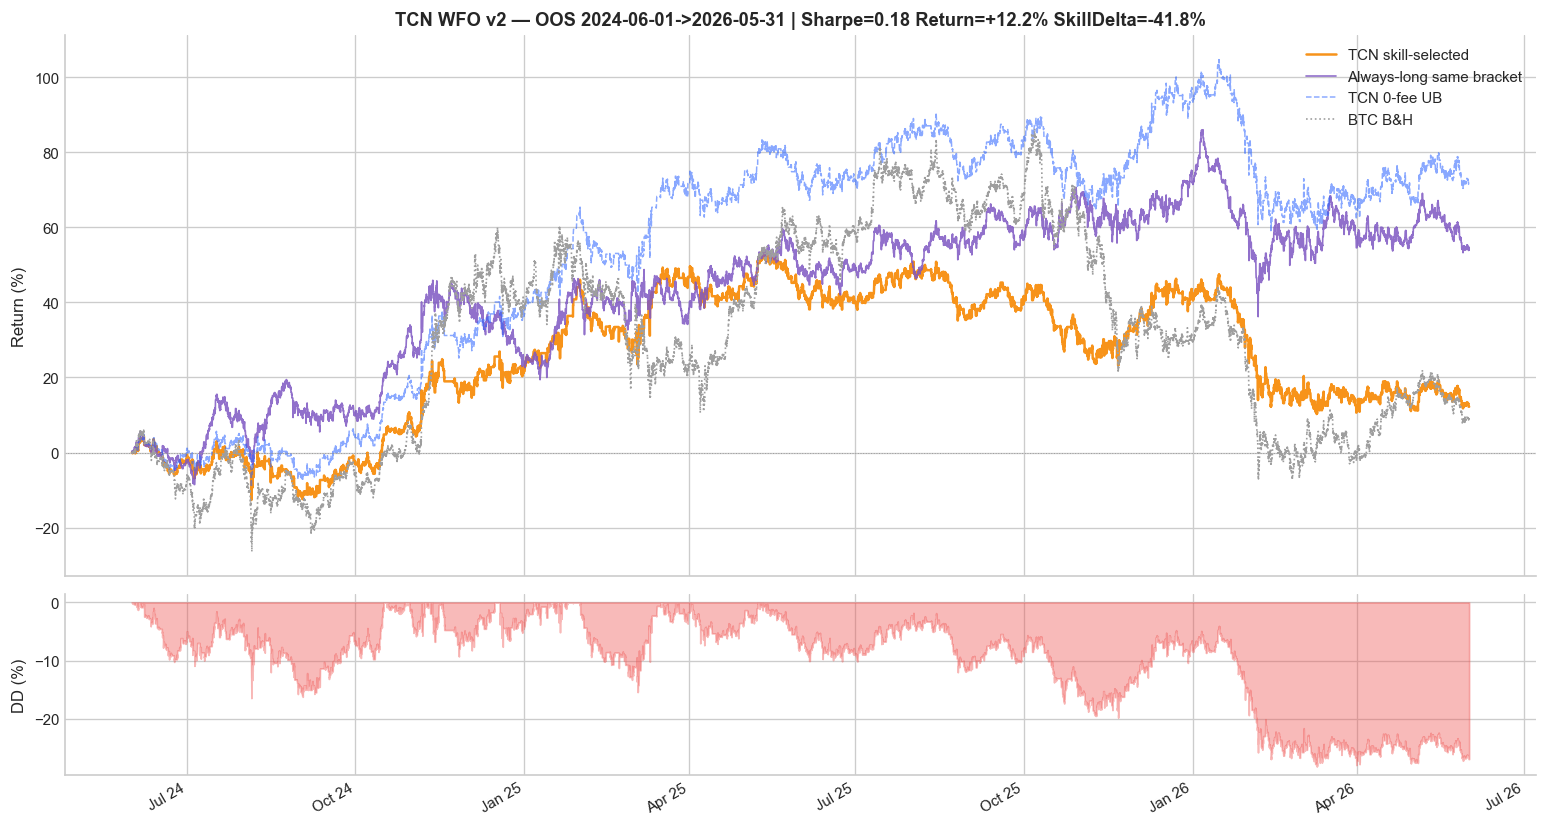

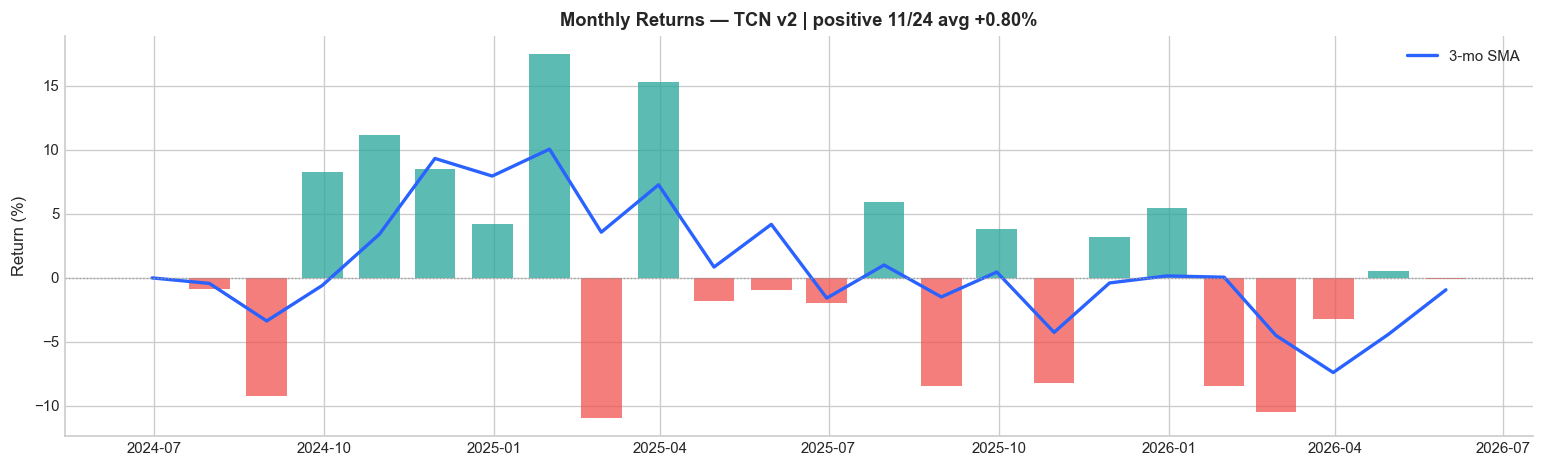

In [8]:
o_p = oos_probs_series.values
o_idx = oos_probs_series.index
o_df = df.loc[o_idx].copy()
o_close = o_df["close"].values; o_high = o_df["high"].values; o_low = o_df["low"].values; o_atr = o_df["atr_14_pct"].values

def _eval_config(label, prob, params, with_fees=True, **exec_kwargs):
    eq, tr, meta = _run_backtest(prob, o_close, o_high, o_low, o_atr, with_fees=with_fees, **exec_kwargs, **params)
    return {"label": label, "eq": eq, "trades": tr if len(tr) else pd.DataFrame(columns=["direction", "reason", "gross", "net", "hold"]),
            "meta": meta, "metrics": _bt_metrics(eq, tr, meta)}

def _matching_baseline_runs(params):
    runs = []
    if params["trade_direction"] in ("both", "long_only"):
        runs.append(_eval_config("Always-long same bracket", _baseline_probs("long", len(o_p)), params, True))
    if params["trade_direction"] in ("both", "short_only"):
        runs.append(_eval_config("Always-short same bracket", _baseline_probs("short", len(o_p)), params, True))
    return runs

RUNS = []
RUNS.append(_eval_config("TCN skill-selected w/fees", o_p, BEST, True))
RUNS.append(_eval_config("TCN skill-selected 0fee", o_p, BEST, False))
BASELINE_RUNS = _matching_baseline_runs(BEST)
RUNS.extend(BASELINE_RUNS)
RUNS.append(_eval_config("TCN miss-unfilled", o_p, BEST, True, miss_unfilled=True))
for bps in [0, 3, 5, 10]:
    RUNS.append(_eval_config(f"TCN market+taker+{bps}bp", o_p, BEST, True, market_entry=True, slippage_bps=bps))

# Raw-return winner is reported separately as an audit baseline, never as model skill.
RUNS.append(_eval_config("TCN raw-return-selected audit", o_p, BEST_TOTAL, True))
RAW_BASELINE_RUNS = _matching_baseline_runs(BEST_TOTAL)
for r in RAW_BASELINE_RUNS:
    r = dict(r)
    r["label"] = r["label"].replace("same bracket", "raw-return bracket")
    RUNS.append(r)

metrics_df = pd.DataFrame([{**r["metrics"], "label": r["label"]} for r in RUNS])
cols = ["label", "total_ret", "sharpe", "sortino", "maxdd", "n_trades", "n_long", "n_short", "win_rate",
        "avg_net", "median_net", "tp_rate", "sl_rate", "timeout_rate", "exposure", "maker_entries", "taker_entries", "missed_entries"]
display(metrics_df[cols])

PRIMARY = RUNS[0]
eq_fees, TF = PRIMARY["eq"], PRIMARY["trades"]
eq_0fee, T0 = RUNS[1]["eq"], RUNS[1]["trades"]
best_baseline = max(BASELINE_RUNS, key=lambda r: r["metrics"]["sharpe"])
skill_delta_ret = float(eq_fees[-1] - best_baseline["eq"][-1])
skill_delta_sharpe = float(_sharpe(eq_fees) - _sharpe(best_baseline["eq"]))
print(f"Skill delta vs {best_baseline['label']}: ret={skill_delta_ret:+.1%}, sharpe={skill_delta_sharpe:+.3f}")

bh = (o_close / o_close[0] - 1) * 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[3, 1], sharex=True)
ax1.plot(o_idx, (eq_fees - 1) * 100, color=ACCENT, lw=1.5, label="TCN skill-selected")
ax1.plot(o_idx, (best_baseline["eq"] - 1) * 100, color=PURPLE, lw=1.0, alpha=0.85, label=best_baseline["label"])
ax1.plot(o_idx, (eq_0fee - 1) * 100, color=BLUE, lw=0.9, ls="--", alpha=0.55, label="TCN 0-fee UB")
ax1.plot(o_idx, bh, color=GREY, lw=1.0, ls=":", label="BTC B&H")
ax1.axhline(0, color=GREY, lw=0.6, ls=":")
ax1.set_ylabel("Return (%)"); ax1.legend()
ax1.set_title(f"TCN WFO v2 — OOS {OOS_START.date()}->{o_idx[-1].date()} | "
              f"Sharpe={_sharpe(eq_fees):.2f} Return={eq_fees[-1]-1:+.1%} "
              f"SkillDelta={skill_delta_ret:+.1%}", fontweight="bold")
pk = np.maximum.accumulate(eq_fees); dd = (eq_fees - pk) / pk * 100
ax2.fill_between(o_idx, dd, 0, color=RED, alpha=0.4)
ax2.set_ylabel("DD (%)")
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.tight_layout(); fig.savefig(ARTS_DIR / "01_equity_drawdown.png"); plt.show()

eqs = pd.Series(eq_fees, index=o_idx)
mret = eqs.resample("ME").last().pct_change().fillna(0) * 100
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(mret.index, mret.values, color=[GREEN if r >= 0 else RED for r in mret], width=22, alpha=0.75)
ax.plot(mret.index, mret.rolling(3, min_periods=1).mean(), color=BLUE, lw=2, label="3-mo SMA")
ax.axhline(0, color=GREY, lw=0.8, ls=":")
ax.set_ylabel("Return (%)"); ax.legend()
ax.set_title(f"Monthly Returns — TCN v2 | positive {int((mret>0).sum())}/{len(mret)} avg {mret.mean():+.2f}%", fontweight="bold")
fig.tight_layout(); fig.savefig(ARTS_DIR / "02_monthly_returns.png"); plt.show()


## 8 · Robustness Checks

In [9]:
REGIME_DATES = {
    "chop": (pd.Timestamp("2024-06-01"), pd.Timestamp("2024-11-05")),
    "bull": (pd.Timestamp("2024-11-06"), pd.Timestamp("2025-10-31")),
    "bear": (pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31 23:00:00")),
}

print("=== Regime breakdown: TCN vs selected same-bracket baseline ===")
reg_rows = []
for reg, (s, e) in REGIME_DATES.items():
    m = (o_idx >= s) & (o_idx <= e)
    if m.sum() > 24:
        seg = eq_fees[m] / eq_fees[m][0]
        bseg = best_baseline["eq"][m] / best_baseline["eq"][m][0]
        bhseg = o_close[m] / o_close[m][0]
        reg_rows.append({"regime": reg, "tcn_ret": seg[-1] - 1, "base_ret": bseg[-1] - 1,
                         "skill_delta": seg[-1] - bseg[-1], "bh_ret": bhseg[-1] - 1,
                         "tcn_sharpe": _sharpe(seg), "tcn_maxdd": _maxdd(seg)})
display(pd.DataFrame(reg_rows))

print("=== Delay robustness ===")
delay_rows = []
for lag in [0, 1, 2, 6, 24]:
    p_lag = pd.Series(o_p, index=o_idx).shift(lag).values
    eq, tr, meta = _run_backtest(p_lag, o_close, o_high, o_low, o_atr, with_fees=True, **BEST)
    delay_rows.append({"lag_h": lag, "ret": eq[-1] - 1, "sharpe": _sharpe(eq),
                       "maxdd": _maxdd(eq), "trades": len(tr), "exposure": meta["exposure"]})
display(pd.DataFrame(delay_rows))

print("=== Bracket geometry checks on always-long baseline ===")
geom_rows = []
for sl, tp, label in [(1.0, 1.0, "symmetric_1_1"), (2.5, 2.5, "symmetric_2_5"),
                      (BEST["sl_atr_mult"], BEST["tp_atr_mult"], "selected")]:
    p = {**BEST, "sl_atr_mult": sl, "tp_atr_mult": tp, "trade_direction": "long_only"}
    eq, tr, meta = _run_backtest(_baseline_probs("long", len(o_p)), o_close, o_high, o_low, o_atr, with_fees=True, **p)
    geom_rows.append({"case": label, "sl": sl, "tp": tp, **_bt_metrics(eq, tr, meta)})
display(pd.DataFrame(geom_rows))

print("=== Exposure-matched random-entry null ===")
rng = np.random.default_rng(SEED)
n_sims = 300
n = len(o_p)
n_tr = len(TF)
rets = []
for _ in range(n_sims):
    s = np.full(n, 0.5, dtype=float)
    locs = rng.choice(n, size=min(max(n_tr, 2), n), replace=False)
    if BEST["trade_direction"] == "short_only":
        s[locs] = BEST["short_threshold"] - 0.05
    else:
        s[locs] = BEST["long_threshold"] + 0.05
    eq, _, _ = _run_backtest(s, o_close, o_high, o_low, o_atr, with_fees=True, **BEST)
    rets.append(eq[-1] - 1)
rets = np.array(rets)
real = eq_fees[-1] - 1
print({"real_ret": real, "null_p50": float(np.percentile(rets, 50)),
       "null_p95": float(np.percentile(rets, 95)), "pctile": float((rets < real).mean()),
       "note": "This is diagnostic only; always-long/always-short is the stronger baseline for bracket beta."})


=== Regime breakdown: TCN vs selected same-bracket baseline ===


,regime,tcn_ret,base_ret,skill_delta,bh_ret,tcn_sharpe,tcn_maxdd
0,chop,0.0614,0.2776,-0.2161,0.0055,0.4080,-0.1646
1,bull,0.1780,0.2342,-0.0562,0.5376,0.5514,-0.1740
2,bear,-0.1334,-0.0848,-0.0485,-0.3286,-0.7370,-0.2521


=== Delay robustness ===


,lag_h,ret,sharpe,maxdd,trades,exposure
0,0,0.1220,0.1797,-0.2823,625,0.4788
1,1,0.1901,0.2830,-0.2441,618,0.4743
2,2,0.8689,1.0079,-0.1928,615,0.4753
3,6,-0.0988,-0.1662,-0.3196,637,0.4800
4,24,0.4576,0.6208,-0.2436,603,0.4581


=== Bracket geometry checks on always-long baseline ===


,case,sl,tp,n_trades,n_long,n_short,win_rate,avg_net,median_net,tp_rate,sl_rate,timeout_rate,total_ret,sharpe,sortino,maxdd,exposure,maker_entries,taker_entries,missed_entries
0,symmetric_1_1,1.0000,1.0000,963,963,0,0.4891,-0.0001,-0.0013,0.4683,0.4496,0.0810,-0.1637,-0.2628,-0.2498,-0.3961,0.5606,403,560,0
1,symmetric_2_5,2.5000,2.5000,651,651,0,0.5038,-0.0003,0.0002,0.2320,0.2320,0.5361,-0.2589,-0.3967,-0.4217,-0.4508,0.7030,259,392,0
2,selected,1.0000,2.0000,825,825,0,0.3927,0.0006,-0.0075,0.2752,0.5297,0.1939,0.5397,0.6282,0.6724,-0.2677,0.6236,335,490,0


=== Exposure-matched random-entry null ===
{'real_ret': np.float64(0.12203629348529765), 'null_p50': 0.14665637530721887, 'null_p95': 0.6901830717877226, 'pctile': 0.46, 'note': 'This is diagnostic only; always-long/always-short is the stronger baseline for bracket beta.'}


## 9 · Save Local Artifacts

In [10]:
np.save(ARTS_DIR / "oos_probs.npy", oos_probs_series.values.astype(np.float32))
np.save(ARTS_DIR / "oos_probs_raw.npy", oos_raw_probs_series.values.astype(np.float32))
np.save(ARTS_DIR / "oos_pdown.npy", (1.0 - oos_probs_series.values).astype(np.float32))
np.save(ARTS_DIR / "oos_pdown_raw.npy", (1.0 - oos_raw_probs_series.values).astype(np.float32))
np.save(ARTS_DIR / "oos_index.npy", oos_probs_series.index.astype("datetime64[ns]").astype(np.int64).values)

wfo_idx = df.index
np.save(ARTS_DIR / "wfo_probs.npy", probs.astype(np.float32))
np.save(ARTS_DIR / "wfo_probs_raw.npy", probs_raw.astype(np.float32))
np.save(ARTS_DIR / "wfo_pdown.npy", (1.0 - probs).astype(np.float32))
np.save(ARTS_DIR / "wfo_index.npy", wfo_idx.astype("datetime64[ns]").astype(np.int64).values)

grid_df.head(200).to_csv(ARTS_DIR / "trading_grid_leaderboard.csv", index=False)
grid_total_df.head(200).to_csv(ARTS_DIR / "trading_grid_total_return_audit.csv", index=False)
metrics_df.to_csv(ARTS_DIR / "oos_robustness_metrics.csv", index=False)

results = {
    "notebook": "03_tcn_v2",
    "created": pd.Timestamp.now().isoformat(),
    "model": "TCNMultiTask WFO (direction + forward-vol)",
    "selection": "Trading grid selected by skill_sharpe_delta and skill_ret_delta over same-bracket always-long/always-short baselines; OOS held out.",
    "skill_positive_on_grid_validation": SKILL_POSITIVE,
    "splits": {"grid_val_start": str(GRID_VAL_START.date()), "grid_val_end": str(GRID_VAL_END.date()),
               "oos_start": str(OOS_START.date()), "oos_end": str(OOS_END)},
    "wfo": {"scheme": WFO_SCHEME, "wfo_start": str(WFO_START.date()),
            "retrain_months": RETRAIN_MONTHS, "embargo_h": EMBARGO_H, "folds": fold_log},
    "tbm": {"mult": TBM_MULT, "vol_window": TBM_VOL_WINDOW, "vert_h": TBM_VERT_H},
    "architecture": {"channels": TCN_CHANNELS, "kernel": TCN_KERNEL, "dropout": TCN_DROPOUT,
                     "seq_len": SEQ_LEN, "n_features": N_FEATURES, "n_params": n_params,
                     "receptive_field": rf},
    "training": {"epochs": EPOCHS, "patience": PATIENCE, "lambda_vol": LAMBDA_VOL},
    "oos_auc_tbm_raw": round(float(auc_oos_raw), 4),
    "oos_auc_tbm_signal": round(float(auc_oos_signal), 4),
    "all_features": ALL_FEATURES,
    "best_params_skill_selected": BEST_SKILL,
    "best_params_raw_return_audit": BEST_TOTAL,
    "grid_validation_best_skill_row": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
                                       for k, v in grid_df.iloc[0].to_dict().items()},
    "backtest_wfees": _bt_metrics(eq_fees, TF, PRIMARY["meta"]),
    "backtest_0fee": _bt_metrics(eq_0fee, T0, RUNS[1]["meta"]),
    "same_bracket_baselines": {
        r["label"]: r["metrics"] for r in BASELINE_RUNS
    } | {
        "selected_baseline": best_baseline["label"],
        "skill_delta_vs_selected_baseline": {"ret": round(skill_delta_ret, 4), "sharpe": round(skill_delta_sharpe, 4)},
    },
    "execution_stress": {r["label"]: r["metrics"] for r in RUNS if "market+taker" in r["label"] or "miss-unfilled" in r["label"]},
    "raw_return_audit": {
        "tcn_raw_return_selected": next(r for r in RUNS if r["label"] == "TCN raw-return-selected audit")["metrics"],
        "matching_baselines": {r["label"]: r["metrics"] for r in RUNS if "raw-return bracket" in r["label"]},
    },
    "monthly": {"mean_pct": round(float(mret.mean()), 3),
                "positive_months": int((mret > 0).sum()), "total_months": int(len(mret))},
    "artifacts": {"oos_probs": "oos_probs.npy", "oos_pdown": "oos_pdown.npy",
                  "oos_index": "oos_index.npy (int64 ns)", "wfo_probs": "wfo_probs.npy",
                  "wfo_pdown": "wfo_pdown.npy", "model": "model_lastfold.pt",
                  "skill_grid": "trading_grid_leaderboard.csv",
                  "raw_return_grid_audit": "trading_grid_total_return_audit.csv",
                  "robustness_metrics": "oos_robustness_metrics.csv"},
}
json.dump(results, open(ARTS_DIR / "results.json", "w"), indent=2, default=float)
print(json.dumps({k: v for k, v in results.items() if k not in ("all_features", "wfo")}, indent=2)[:3000])
print(f"Artifacts saved -> {ARTS_DIR}")


{
  "notebook": "03_tcn_v2",
  "created": "2026-06-21T19:27:49.042940",
  "model": "TCNMultiTask WFO (direction + forward-vol)",
  "selection": "Trading grid selected by skill_sharpe_delta and skill_ret_delta over same-bracket always-long/always-short baselines; OOS held out.",
  "skill_positive_on_grid_validation": true,
  "splits": {
    "grid_val_start": "2023-06-01",
    "grid_val_end": "2024-05-31",
    "oos_start": "2024-06-01",
    "oos_end": "2026-05-31 23:00:00"
  },
  "tbm": {
    "mult": 2.0,
    "vol_window": 24,
    "vert_h": 24
  },
  "architecture": {
    "channels": [
      64,
      64,
      64,
      64
    ],
    "kernel": 3,
    "dropout": 0.2,
    "seq_len": 48,
    "n_features": 32,
    "n_params": 96003,
    "receptive_field": 61
  },
  "training": {
    "epochs": 80,
    "patience": 10,
    "lambda_vol": 0.5
  },
  "oos_auc_tbm_raw": 0.5243,
  "oos_auc_tbm_signal": 0.5273,
  "best_params_skill_selected": {
    "long_threshold": 0.6,
    "short_threshold": 0.4,
